# Analyzing coincident detections

Code to plot both the lightcurve and show the relevant images of a detection

In [1]:
import os
import sys

# Path to the ColibriPipeline package so we can reuse the production helpers.
# Reuse only path-agnostic library modules (cir/cp/getRAdec) -- NOT
# generate_specific_lightcurve, which hard-codes COMPUTERNAME and D:/ paths.
path_add = r"C:\Users\GreenBird\Documents\GitHub\ColibriPipeline\ColibriPipeline"
if path_add not in sys.path:
    sys.path.append(path_add)

import glob
import warnings
from dataclasses import dataclass, field
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sep
from astropy import wcs
from astropy.io import fits
from astropy.time import Time

import colibri_image_reader as cir
import colibri_photometry as cp
import getRAdec

# Pipeline-wide constants (mirrors generate_specific_lightcurve.py / lightcurve_maker.py)
MINDIR_FORMAT    = "%Y%m%d_%H.%M.%S.%f"   # minute-directory name format
TIMESTAMP_FORMAT = "%Y-%m-%dT%H:%M:%S.%f"  # DATE-OBS header format
EXPOSURE_TIME    = 0.025   # s/frame
APERTURE_RADIUS  = 3.0     # px
EXCLUDE_IMAGES   = 1
SEC_TO_SAVE      = 1.0     # s on either side of the event
DRIFT_TOLERANCE  = 1.0     # px/s: above this we refuse to build a curve
DRIFT_THRESHOLD  = 0.025   # px/s: above this we apply a drift correction
COORD_TOLERANCE  = 0.002   # deg (~7"): RA/Dec match tolerance (simultaneous_occults.py)
TIME_TOLERANCE   = 1.0     # s: event-time match tolerance
IMG_DIM          = 2048    # detector size (px), used for FOV bounds checks

In [2]:
@dataclass
class Telescope:
    """Everything path-dependent for one telescope, so no ad-hoc drive-letter
    rewrites are scattered through the notebook."""
    name:    str          # "RED" / "GREEN" / "BLUE" (matches *BIRD suffix)
    color:   str          # plot colour
    archive: str          # ColibriArchive root (det/art/.npy/.fits live here)
    data:    str          # ColibriData root (raw minute dirs + .rcd live here)
    drive:   str          # drive letter, e.g. "R:"  (for rewriting stored .rcd paths)
    det_files: list = field(default_factory=list)  # populated below

    @property
    def archive_date(self):
        return os.path.join(self.archive, OBS_DATE)            # hyphenated date

    @property
    def data_date(self):
        return os.path.join(self.data, OBS_DATE.replace("-", ""))  # YYYYMMDD


# ------------------------------------------------------------------
# Configure the night and the telescopes to consider.
# ------------------------------------------------------------------
OBS_DATE = "2026-06-16"   # hyphenated, as used under ColibriArchive

TELESCOPES = [
    Telescope("RED",   "red",   archive=r"R:\ColibriArchive", data=r"R:\ColibriData", drive="R:"),
    Telescope("GREEN", "green", archive=r"D:\ColibriArchive", data=r"D:\ColibriData", drive="D:"),
    Telescope("BLUE",  "blue",  archive=r"B:\ColibriArchive", data=r"B:\ColibriData", drive="B:"),
]
TEL_BY_NAME = {t.name: t for t in TELESCOPES}


def load_det_files(tel):
    """Detection .txt files in a telescope's archive for OBS_DATE.

    Missing archive (e.g. telescope offline / drive not mounted) is reported,
    not raised, so a telescope can legitimately have zero detections."""
    d = tel.archive_date
    if not os.path.isdir(d):
        print(f"WARNING: {tel.name} archive not found: {d}  (telescope offline / drive unmounted?)")
        return []
    return [f for f in os.listdir(d) if f.startswith("det") and f.endswith(".txt")]


for tel in TELESCOPES:
    tel.det_files = load_det_files(tel)
    print(f"{tel.name:5s}: {len(tel.det_files)} detection files in {tel.archive_date}")

# Quick peek
for tel in TELESCOPES:
    if tel.det_files:
        print(f"  e.g. {tel.det_files[0]}")
        break

RED  : 1746 detection files in R:\ColibriArchive\2026-06-16
GREEN: 3038 detection files in D:\ColibriArchive\2026-06-16
BLUE : 2093 detection files in B:\ColibriArchive\2026-06-16
  e.g. det_2026-06-16_052108_607401000_star9_REDBIRD.txt


In [14]:
def parse_header(file_path):
    """Parse the commented '# key: value' header of a det_/art_ .txt file."""
    metadata = {}
    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()
            if line.startswith("#"):
                line_content = line[1:].strip()
                if ":" in line_content:
                    key, value = map(str.strip, line_content.split(":", 1))
                    metadata[key] = value
            else:
                break  # stop at the data table
    return metadata


# ------------------------------------------------------------------
# Header / filename accessors
# ------------------------------------------------------------------
def get_event_datetime(filename):
    """Full event datetime parsed from a det_/art_ filename.

    det_2026-06-16_050404_531339000_starN_TELESCOPE.txt
        -> date=2026-06-16, time=050404 (HHMMSS), frac=531339000 (ns).
    Parsing the *date* too (not just the time) avoids spurious matches across
    midnight."""
    parts = os.path.basename(filename).split("_")
    date_str = parts[1]                       # YYYY-MM-DD
    hms      = parts[2]                        # HHMMSS
    frac_us  = parts[3][:6]                    # ns -> us (6 digits)
    return datetime.strptime(f"{date_str}_{hms}.{frac_us}", "%Y-%m-%d_%H%M%S.%f")


def get_radec(archive_dir, filename):
    """(RA, Dec) in degrees from the 'RA Dec Coords' header line.

    Returns (inf, inf) and warns if the line is missing -- this means the file
    predates WCS solving (see coordsfinder.py) and the data needs reprocessing
    before it can be cross-matched by sky position."""
    meta = parse_header(os.path.join(archive_dir, filename))
    if "RA Dec Coords" not in meta:
        warnings.warn(f"No 'RA Dec Coords' in {filename} -- reprocess (no WCS solution).")
        return float("inf"), float("inf")
    ra, dec = (float(v) for v in meta["RA Dec Coords"].split()[:2])
    return ra, dec


def get_star_coords(archive_dir, filename):
    """Pixel (x, y) of the star on that telescope, from the header."""
    meta = parse_header(os.path.join(archive_dir, filename))
    return np.array([float(c) for c in meta["Star Coords"].split()])


def radec_match(c1, c2, tol_deg=COORD_TOLERANCE):
    """Declination-corrected angular separation test (simultaneous_occults.py:373)."""
    if not (np.all(np.isfinite(c1)) and np.all(np.isfinite(c2))):
        return False
    ra1, dec1 = c1
    ra2, dec2 = c2
    sep_deg = np.hypot((ra1 - ra2) / np.cos(np.radians(dec1)), dec1 - dec2)
    return sep_deg <= tol_deg


# ------------------------------------------------------------------
# Path / minute-directory helpers
# ------------------------------------------------------------------
def rcd_path(tel, raw_path):
    """Rewrite a stored .rcd path's drive letter to telescope `tel`'s drive.

    Detection files record .rcd paths with whatever drive the *processing*
    machine used; to read them from another telescope's archive we swap the
    leading 'X:' prefix.  Replaces the scattered '.replace(\"d:\", \"B:\")' hacks."""
    raw_path = str(raw_path)
    if len(raw_path) >= 2 and raw_path[1] == ":":
        return tel.drive + raw_path[2:]
    return raw_path


def list_minute_dirs(tel):
    """[(start_datetime, name, fullpath)] for every minute dir of OBS_DATE.

    Existence of a covering minute directory is the ground truth for "was this
    telescope observing then?"."""
    out = []
    d = tel.data_date
    if not os.path.isdir(d):
        return out
    for name in os.listdir(d):
        full = os.path.join(d, name)
        if not os.path.isdir(full) or name == "Dark":
            continue
        try:
            t = datetime.strptime(name + "000", MINDIR_FORMAT)  # name has ms; pad to us
        except ValueError:
            continue
        out.append((t, name, full))
    return sorted(out)


def find_minute_dir(tel, event_dt):
    """Minute dir whose [t, t+60s) window contains event_dt, else None."""
    for t, name, full in list_minute_dirs(tel):
        if t <= event_dt < t + timedelta(minutes=1.1):
            return name, full
    return None

In [4]:
# ==================================================================
# Cross-telescope matching by TIME + RA/Dec (not raw pixels!)
# ------------------------------------------------------------------
# Telescopes have different fields/orientations, so the same star sits at
# different pixel coords on each one.  We match on sky position (RA/Dec from
# the header, written by coordsfinder.py) within COORD_TOLERANCE, exactly like
# the production simultaneous_occults.py.
#
# Crucially, PARTIAL matches are kept: a candidate seen by 2 of 3 telescopes is
# recorded with the third marked missing -- it is NOT discarded.  That is the
# whole point of investigating a "Red is missing" event.
# ==================================================================

# Pre-compute (event time, RA/Dec) for every detection, once.
records = {}
for tel in TELESCOPES:
    recs = []
    for f in tel.det_files:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")  # summarised below instead of per-file
            radec = np.array(get_radec(tel.archive_date, f))
        recs.append({"file": f, "dt": get_event_datetime(f), "radec": radec})
    records[tel.name] = recs
    n_nowcs = sum(1 for r in recs if not np.all(np.isfinite(r["radec"])))
    if n_nowcs:
        print(f"WARNING: {tel.name}: {n_nowcs}/{len(recs)} detections lack RA/Dec "
              f"(no WCS) and cannot be sky-matched -- reprocess to fix.")


def build_candidates():
    """Group detections into coincident candidates across telescopes.

    Returns a list of dicts: {files: {tel: filename}, radec, event_dt,
    present: [tel...], missing: [tel...]}.  Only multi-telescope coincidences
    (>=2) are returned; isolated single-telescope detections are ignored."""
    consumed = set()          # (tel_name, filename) already assigned to a candidate
    candidates = []
    for anchor in TELESCOPES:
        for arec in records[anchor.name]:
            key = (anchor.name, arec["file"])
            if key in consumed:
                continue
            matched = {anchor.name: arec["file"]}
            consumed.add(key)
            for other in TELESCOPES:
                if other.name == anchor.name:
                    continue
                for orec in records[other.name]:
                    okey = (other.name, orec["file"])
                    if okey in consumed:
                        continue
                    if (abs((arec["dt"] - orec["dt"]).total_seconds()) <= TIME_TOLERANCE
                            and radec_match(arec["radec"], orec["radec"])):
                        matched[other.name] = orec["file"]
                        consumed.add(okey)
                        break
            present = [t.name for t in TELESCOPES if t.name in matched]
            if len(present) < 2:
                continue  # not a coincidence
            candidates.append({
                "files":    matched,
                "radec":    arec["radec"],
                "event_dt": arec["dt"],
                "present":  present,
                "missing":  [t.name for t in TELESCOPES if t.name not in matched],
            })
    return candidates


candidates = build_candidates()

for tel in TELESCOPES:
    print(f"Number of {tel.name:5s} files: {len(tel.det_files)}")
print(f"\nNumber of coincident candidates: {len(candidates)}")
n_partial = sum(1 for c in candidates if c["missing"])
print(f"  of which partial (a telescope missing): {n_partial}")

Number of RED   files: 1746
Number of GREEN files: 3038
Number of BLUE  files: 2093

Number of coincident candidates: 2
  of which partial (a telescope missing): 2


In [5]:
# Summarise candidates.  Partial candidates (a telescope missing) are flagged
# up front -- these are the ones to investigate.
summary_rows = []
for i, c in enumerate(candidates):
    summary_rows.append({
        "idx":      i,
        "event":    c["event_dt"].strftime("%H:%M:%S.%f")[:-3],
        "RA":       round(c["radec"][0], 4),
        "Dec":      round(c["radec"][1], 4),
        "present":  ",".join(c["present"]),
        "MISSING":  ",".join(c["missing"]) or "-",
    })
candidates_df = pd.DataFrame(summary_rows)
print(candidates_df.to_string(index=False) if len(candidates_df) else "No candidates.")

# Indices of partial candidates, for quick selection below.
partial_idxs = [r["idx"] for r in summary_rows if r["MISSING"] != "-"]
print(f"\nPartial-candidate indices (a telescope missing): {partial_idxs}")

 idx        event       RA      Dec    present MISSING
   0 05:44:17.580 278.9944 -22.7176 GREEN,BLUE     RED
   1 07:15:55.284 279.4588 -23.3967 GREEN,BLUE     RED

Partial-candidate indices (a telescope missing): [0, 1]


Inspecting candidate 0: present=['GREEN', 'BLUE'], missing=['RED']


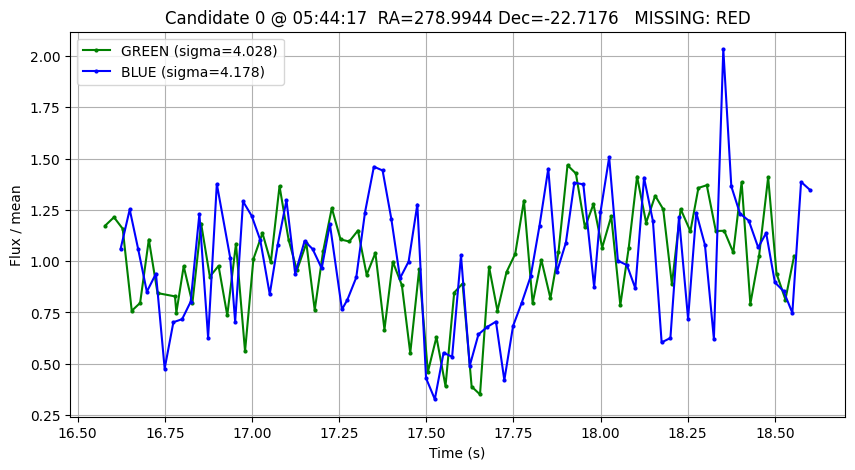

C:\Users\GreenBird\AppData\Local\Temp\ipykernel_16044\2508523965.py:49: RuntimeWarning: divide by zero encountered in log
  ax.imshow(np.log(images[0]), cmap="gray")
C:\Users\GreenBird\AppData\Local\Temp\ipykernel_16044\2508523965.py:49: RuntimeWarning: divide by zero encountered in log
  ax.imshow(np.log(images[0]), cmap="gray")


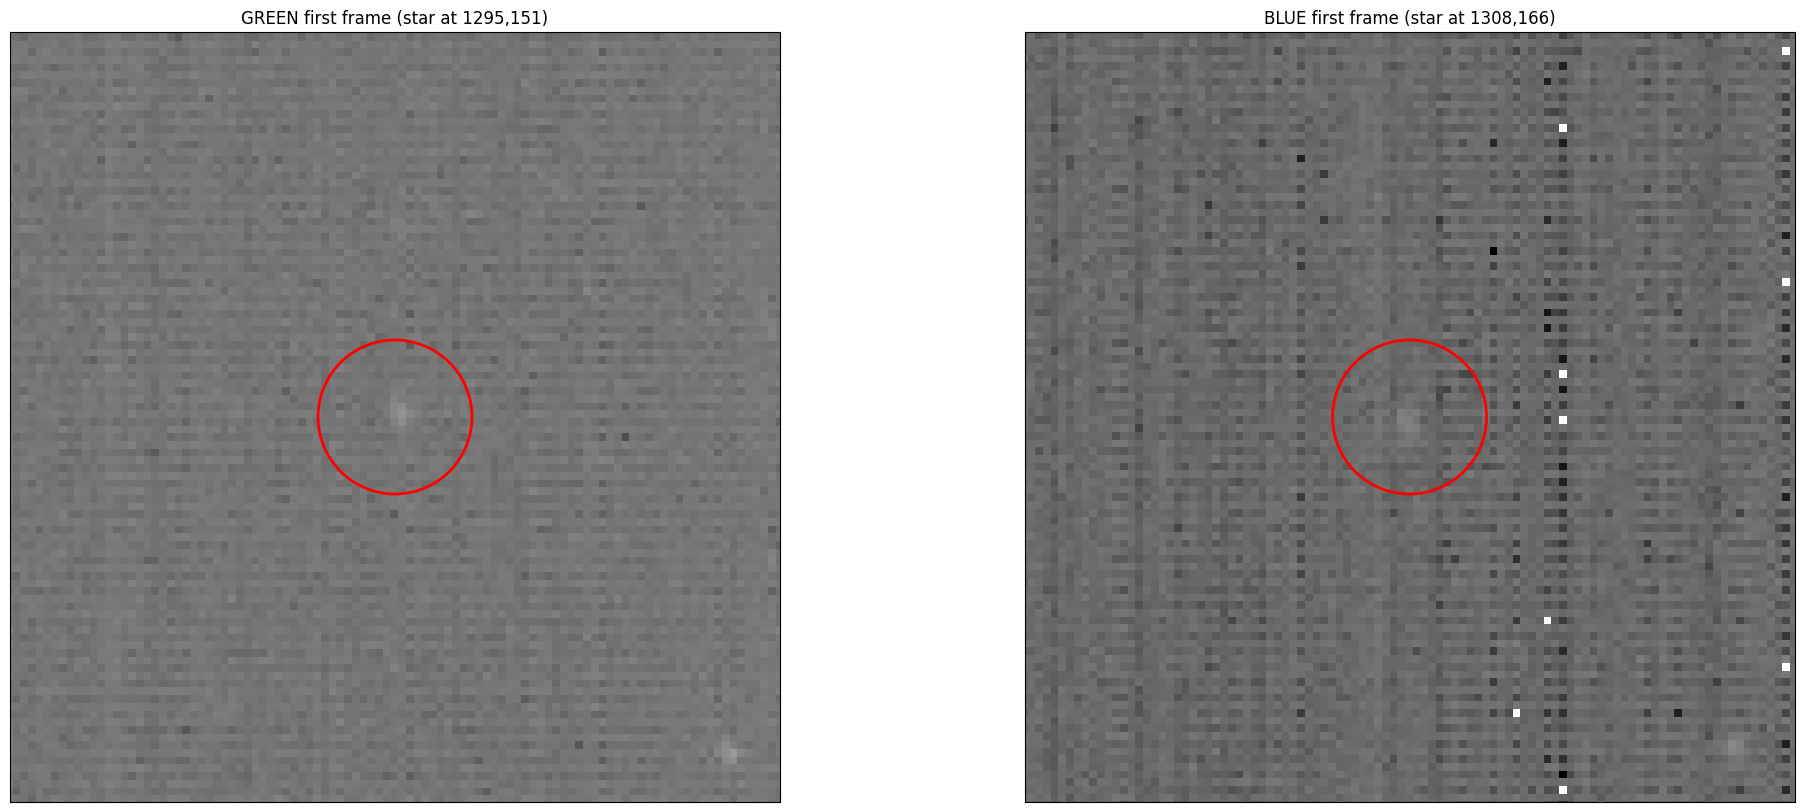

In [6]:
# ------------------------------------------------------------------
# Plot a candidate's light curves across whichever telescopes are present.
# Missing telescopes are noted in the title instead of crashing.
# ------------------------------------------------------------------
def load_lightcurve(tel, filename):
    """(DataFrame, header dict) for one det_/art_ file."""
    path = os.path.join(tel.archive_date, filename)
    df = pd.read_csv(path, delim_whitespace=True, skiprows=lambda x: x < 19,
                     names=["filename", "time", "flux", "conv_flux"])
    return df, parse_header(path)


def plot_candidate(idx, normalize=True):
    cand = candidates[idx]
    plt.figure(figsize=(10, 5))
    for name in cand["present"]:
        tel = TEL_BY_NAME[name]
        df, meta = load_lightcurve(tel, cand["files"][name])
        sig = meta.get("significance", "n/a")
        flux = df["flux"] / np.mean(df["flux"]) if normalize else df["flux"]
        plt.plot(df["time"], flux, marker="o", markersize=2,
                 color=tel.color, label=f"{name} (sigma={sig})")
    miss = ", ".join(cand["missing"]) or "none"
    plt.xlabel("Time (s)")
    plt.ylabel("Flux / mean" if normalize else "Flux")
    plt.title(f"Candidate {idx} @ {cand['event_dt'].strftime('%H:%M:%S')}  "
              f"RA={cand['radec'][0]:.4f} Dec={cand['radec'][1]:.4f}   MISSING: {miss}")
    plt.legend(); plt.grid()
    plt.show()


# Choose a candidate to inspect.  Default to the first partial one if any.
detect_idx = partial_idxs[0] if partial_idxs else 0
print(f"Inspecting candidate {detect_idx}: present={candidates[detect_idx]['present']}, "
      f"missing={candidates[detect_idx]['missing']}")
plot_candidate(detect_idx)


# Zoomed first-frame images for each present telescope (uses rcd_path to read
# each telescope's .rcd from its own drive -- no more manual drive swaps).
present = candidates[detect_idx]["present"]
fig, axes = plt.subplots(1, len(present), figsize=(12 * len(present), 10), squeeze=False)
for ax, name in zip(axes[0], present):
    tel = TEL_BY_NAME[name]
    df, meta = load_lightcurve(tel, candidates[detect_idx]["files"][name])
    frame_paths = [rcd_path(tel, p) for p in df["filename"].values]
    images = cir.importFramesRCD(frame_paths, 30, 10)[0]
    sx, sy = get_star_coords(tel.archive_date, candidates[detect_idx]["files"][name])
    ax.imshow(np.log(images[0]), cmap="gray")
    ax.add_patch(plt.Circle((sx, sy), 10, color="red", fill=False, linewidth=2))
    ax.set_xlim(sx - 50, sx + 50); ax.set_ylim(sy - 50, sy + 50)
    ax.set_title(f"{name} first frame (star at {sx:.0f},{sy:.0f})")
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

# Verifying a candidate (missing telescope / timing)

When a telescope's curve is absent (e.g. **Red**), this section determines *why*, from the data itself, before deciding whether the candidate is real. For each telescope it checks, cheapest first:

1. **Observing?** — was there a minute directory under `ColibriData/{YYYYMMDD}` covering the event time. If not, that telescope simply **was not observing** this star.
2. **Processed?** — does `{minute}_stars.npy` exist in the archive.
3. **In FOV?** — does the star's RA/Dec land on the detector (via the solved star list, or by reverse-mapping RA/Dec through the minute's `*_wcs.fits`).

It also reports the **per-telescope frame-time offset** (from the `unix_time` column of `_stars.npy`), to expose a clock/timestamp mismatch between telescopes.

In [15]:
# ==================================================================
# Verify WHY a telescope is missing, and check for a timing offset.
# ------------------------------------------------------------------
# For each telescope we answer, cheapest check first:
#   observing? -> was there a minute dir covering the event time
#   processed? -> does {minute}_stars.npy exist
#   in FOV?    -> does the star (RA/Dec) land on the detector
# and we report the cross-telescope frame-time offset from _stars.npy.
# ==================================================================
def load_wcs(tel, minutedir_name):
    """astropy WCS for a minute's solved frame, or None if not solved.

    Reads the existing *_wcs.fits in the archive; does NOT trigger an
    astrometry.net solve (so it is safe/fast to call here)."""
    hits = glob.glob(os.path.join(tel.archive_date, f"*{minutedir_name}*wcs*.fits"))
    if not hits:
        return None
    with fits.open(hits[0]) as hdul:
        return wcs.WCS(hdul[0].header)


def check_in_fov(tel, minutedir_name, radec, tol=COORD_TOLERANCE):
    """Return (in_fov, (x, y)).  in_fov is True/False, or None if undeterminable
    (no WCS-tagged star list and no *_wcs.fits)."""
    # Prefer the solved star list (columns x, y, r, ra, dec) if present.
    for p in glob.glob(os.path.join(tel.archive_date, f"{minutedir_name}_*sig_pos.npy")):
        arr = np.load(p, allow_pickle=True)
        if getattr(arr, "ndim", 0) == 2 and arr.shape[1] >= 5:
            d = np.hypot((arr[:, 3] - radec[0]) / np.cos(np.radians(radec[1])),
                         arr[:, 4] - radec[1])
            j = int(np.argmin(d))
            if d[j] <= tol:
                return True, (float(arr[j, 0]), float(arr[j, 1]))
    # Otherwise reverse-map RA/Dec through the WCS and test detector bounds.
    transform = load_wcs(tel, minutedir_name)
    if transform is not None:
        px = getRAdec.getXYSingle(transform, (radec[0], radec[1]))
        return (0 <= px[0] < IMG_DIM and 0 <= px[1] < IMG_DIM), (float(px[0]), float(px[1]))
    return None, None


def load_frame_times(tel, minutedir_name):
    """Per-frame unix times (s) from {minute}_stars.npy, or None."""
    hits = glob.glob(os.path.join(tel.archive_date, f"{minutedir_name}_stars.npy"))
    if not hits:
        return None
    arr = np.load(hits[0], allow_pickle=True)   # (n_frames, n_stars, 4) = [x, y, flux, unix]
    return arr[:, 0, 3].astype(float)


def verify_candidate(idx):
    cand = candidates[idx]
    radec, ev = cand["radec"], cand["event_dt"]
    print(f"=== Candidate {idx} @ {ev}  RA={radec[0]:.4f} Dec={radec[1]:.4f} ===")
    rows, frame_times = [], {}
    for tel in TELESCOPES:
        name = tel.name
        has_det = name in cand["files"]
        md = find_minute_dir(tel, ev)
        observing = md is not None
        mdname = md[0] if md else None
        processed = bool(glob.glob(os.path.join(tel.archive_date, f"{mdname}_stars.npy"))) if mdname else False
        in_fov, px = check_in_fov(tel, mdname, radec) if mdname else (None, None)
        if processed:
            frame_times[name] = load_frame_times(tel, mdname)

        # Verdict, cheapest explanation first.
        if has_det:
            verdict = "DETECTED"
        elif not observing:
            verdict = "NOT OBSERVING (no minute dir covering event) -> did not observe this star"
        elif not processed:
            verdict = "observing but minute NOT processed (no _stars.npy)"
        elif in_fov is False:
            verdict = "star OUTSIDE FOV -> not observable here"
        elif in_fov is None:
            verdict = "no WCS solution -> cannot confirm FOV (reprocess/solve)"
        else:
            verdict = "observable (observing+in FOV) but NO det/art -> forced-curve job likely failed / sub-threshold"

        rows.append({"tel": name, "det": has_det, "observing": observing,
                     "minute_dir": mdname, "processed": processed,
                     "in_fov": in_fov,
                     "px": None if px is None else (round(px[0]), round(px[1])),
                     "verdict": verdict})
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))

    # Timing offset between telescopes (frame times from _stars.npy).
    avail = {k: v for k, v in frame_times.items() if v is not None and len(v)}
    if len(avail) >= 2:
        ref = next(iter(avail))
        print(f"\nFrame-time check (ref = {ref}):")
        for name, t in avail.items():
            tag = "  <-- ref" if name == ref else \
                  f"  median offset vs {ref}: {np.median(t) - np.median(avail[ref]):+.4f} s"
            print(f"  {name}: nframes={len(t)}  "
                  f"first={Time(t[0], format='unix').iso[11:]}  "
                  f"last={Time(t[-1], format='unix').iso[11:]}{tag}")
    else:
        print("\nFrame-time check: need _stars.npy from >=2 telescopes for this minute.")
    return df


_ = verify_candidate(detect_idx)

=== Candidate 0 @ 2026-06-16 05:44:17.580117  RA=278.9944 Dec=-22.7176 ===
  tel   det  observing            minute_dir  processed  in_fov          px                                                                                        verdict
  RED False       True 20260616_05.43.14.365       True    True (1068, 138) observable (observing+in FOV) but NO det/art -> forced-curve job likely failed / sub-threshold
GREEN  True       True 20260616_05.43.45.639       True    True (1295, 151)                                                                                       DETECTED
 BLUE  True       True 20260616_05.43.45.107       True    True (1308, 166)                                                                                       DETECTED

Frame-time check (ref = RED):
  RED: nframes=2399  first=05:43:14.763  last=05:44:16.470  <-- ref
  GREEN: nframes=2399  first=05:43:45.785  last=05:44:45.747  median offset vs RED: +31.1361 s
  BLUE: nframes=2399  first=05:43:45.255  last=

## Reconstruct the missing telescope's light curve

If verification says the star *was* observable on the missing telescope (it was observing **and** the star falls in its FOV), rebuild the light curve directly from the raw `.rcd` frames at the WCS-mapped pixel — the same photometry the pipeline uses for `art_` curves — and overlay it (dashed) on the telescopes that did detect. This lets you eyeball the dip even when no `det_`/`art_` file was ever written.

RED: no WCS solution for 20260616_05.43.14.365; cannot reconstruct.


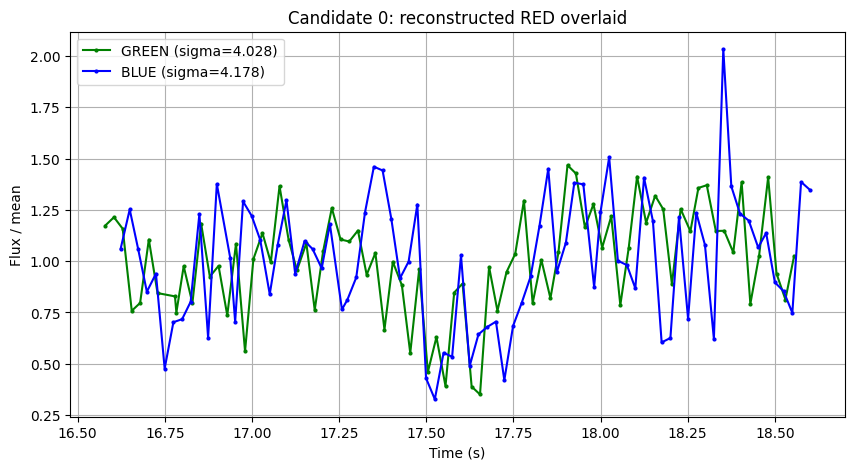

In [16]:
# ==================================================================
# Forced light-curve reconstruction (for a telescope with no det_/art_ file)
# ------------------------------------------------------------------
# Self-contained port of generate_specific_lightcurve.generateLightcurve,
# parameterised by telescope archive/data paths.  Reuses the path-agnostic
# pipeline library functions (cir / cp / sep) so the photometry matches the
# pipeline's art_ curves.  Only runs when verification says the star was
# observable (observing + in FOV), so you can eyeball the dip even with no file.
# ==================================================================
def reconstruct_lightcurve(tel, minutedir_name, minutedir_path, event_dt, radec):
    """Return (times_s, flux) for the star at `radec` on telescope `tel`,
    built straight from the raw .rcd frames.  Returns None on failure
    (no WCS, drift too high, star out of frame)."""
    archive = tel.archive_date

    # WCS reverse-map RA/Dec -> pixel on this telescope
    transform = load_wcs(tel, minutedir_name)
    if transform is None:
        print(f"{tel.name}: no WCS solution for {minutedir_name}; cannot reconstruct.")
        return None
    star_X, star_Y = (float(v) for v in getRAdec.getXYSingle(transform, (radec[0], radec[1])))
    if not (0 <= star_X < IMG_DIM and 0 <= star_Y < IMG_DIM):
        print(f"{tel.name}: star maps to ({star_X:.0f},{star_Y:.0f}) -- outside FOV.")
        return None

    # Master dark for this minute
    mdark_dir = os.path.join(archive, "masterDarks")
    mdark = np.array([(datetime.strptime(d[:-5] + "000", MINDIR_FORMAT),
                       os.path.join(mdark_dir, d)) for d in os.listdir(mdark_dir)])
    dark = cir.chooseDark(Path(minutedir_path), mdark, datetime.strptime(OBS_DATE, "%Y-%m-%d"))

    # Frame bookkeeping (mirrors generate_specific_lightcurve.py:92-122)
    image_paths = sorted(Path(minutedir_path).glob("*.rcd"))
    x_len, y_len, num_images = cir.getSizeRCD(image_paths)
    dir_dt = datetime.strptime(minutedir_name + "000", MINDIR_FORMAT)
    central = int((event_dt - dir_dt).total_seconds() // EXPOSURE_TIME)
    min_f = int(central - 1 - (SEC_TO_SAVE // EXPOSURE_TIME))
    max_f = int(central + 1 + (SEC_TO_SAVE // EXPOSURE_TIME))
    min_f = max(min_f, EXCLUDE_IMAGES + 1)
    max_f = None if max_f >= num_images else max_f
    lc_paths = image_paths[min_f:max_f]

    # Drift estimate: refine the target star's centroid in the first vs. last
    # frame (passing the same position twice would always give zero drift).
    init = np.array([[star_X, star_Y]])
    gauss_sigma = 2.0  # ~PSF sigma; pipeline uses 2*mean_radius/2.355
    first, t0 = cir.importFramesRCD(image_paths, EXCLUDE_IMAGES, 1, dark)
    last,  t1 = cir.importFramesRCD(image_paths, num_images - 1, 1, dark)
    first_pos, _ = cp.refineCentroid(first, t0[0], init, gauss_sigma)
    final_pos, _ = cp.refineCentroid(last,  t1[0], init, gauss_sigma)
    xd, yd = cp.averageDrift(first_pos, final_pos,
                             Time(t0, precision=9).unix, Time(t1, precision=9).unix)
    drift = (abs(xd) > DRIFT_THRESHOLD) or (abs(yd) > DRIFT_THRESHOLD)
    if (abs(xd) > DRIFT_TOLERANCE) or (abs(yd) > DRIFT_TOLERANCE):
        print(f"{tel.name}: drift too high ({xd:.3f},{yd:.3f} px/s); reconstruction unreliable.")
        return None

    # Per-frame aperture photometry at the mapped pixel
    star_data = np.empty((len(lc_paths) + 1, 1, 4), dtype=np.float64)
    f0 = sep.sum_circle(first, [star_X], [star_Y], [APERTURE_RADIUS])
    star_data[0] = [[star_X, star_Y, f0[0][0], Time(t0[0], precision=9).unix]]
    times = []
    for i in range(len(lc_paths)):
        img, it = cir.importFramesRCD(lc_paths, i, 1, dark)
        if drift:
            star_data[i + 1] = cp.timeEvolve(img, star_data[i].copy(), it[0],
                                             APERTURE_RADIUS, 1, (x_len, y_len), (xd, yd))
        else:
            star_data[i + 1] = cp.getStationaryFlux(img.reshape(1, *img.shape),
                                                    star_data[i].copy(), it,
                                                    APERTURE_RADIUS, 1, (x_len, y_len))
        times.append(float(it[0].split(":")[-1][:-3]))  # seconds-within-minute
    return np.array(times), star_data[1:, 0, 2]


def overlay_reconstruction(idx, target_name):
    """Plot present telescopes' curves and overlay the reconstructed (dashed)
    curve for `target_name`, the missing telescope."""
    cand = candidates[idx]
    tel = TEL_BY_NAME[target_name]
    md = find_minute_dir(tel, cand["event_dt"])
    if md is None:
        print(f"{target_name} has no minute dir covering the event -- it was NOT observing; "
              f"nothing to reconstruct.")
        return
    res = reconstruct_lightcurve(tel, md[0], md[1], cand["event_dt"], cand["radec"])

    plt.figure(figsize=(10, 5))
    for name in cand["present"]:
        ptel = TEL_BY_NAME[name]
        df, meta = load_lightcurve(ptel, cand["files"][name])
        plt.plot(df["time"], df["flux"] / np.mean(df["flux"]), marker="o", markersize=2,
                 color=ptel.color, label=f"{name} (sigma={meta.get('significance','n/a')})")
    if res is not None:
        t, flux = res
        plt.plot(t, flux / np.mean(flux), linestyle="--", color=tel.color,
                 label=f"{target_name} (reconstructed)")
    plt.xlabel("Time (s)"); plt.ylabel("Flux / mean")
    plt.title(f"Candidate {idx}: reconstructed {target_name} overlaid")
    plt.legend(); plt.grid(); plt.show()


# Reconstruct the missing telescope of the inspected candidate, if it was observable.
if candidates[detect_idx]["missing"]:
    overlay_reconstruction(detect_idx, candidates[detect_idx]["missing"][0])
else:
    print("Inspected candidate has all telescopes present; nothing to reconstruct.")

# Analyzing high sig individual detections

In [9]:
# ------------------------------------------------------------------
# Single-telescope view: rank one telescope's detections by significance.
# ------------------------------------------------------------------
INSPECT_TEL = "BLUE"   # which telescope's individual detections to inspect below

def sort_by_significance(tel):
    """[(filename, significance)] sorted high->low for a telescope's det files."""
    out = []
    for f in tel.det_files:
        try:
            s = float(parse_header(os.path.join(tel.archive_date, f))["significance"])
        except (KeyError, ValueError):
            continue  # e.g. artificial curves whose significance is non-numeric
        out.append((f, s))
    return sorted(out, key=lambda x: x[1], reverse=True)

sorted_dets = {tel.name: sort_by_significance(tel) for tel in TELESCOPES}

print(f"Top 5 {INSPECT_TEL} detections by significance:")
for f, s in sorted_dets[INSPECT_TEL][:5]:
    print(f"  {s:6.3f}  {f}")

Top 5 BLUE detections by significance:
  17.841  det_2026-06-16_080348_476443000_star46_BLUEBIRD.txt
  14.833  det_2026-06-16_071111_123585000_star47_BLUEBIRD.txt
  14.041  det_2026-06-16_074607_784165000_star1_BLUEBIRD.txt
  12.806  det_2026-06-16_063438_553680000_star3_BLUEBIRD.txt
  11.331  det_2026-06-16_061355_280729000_star33_BLUEBIRD.txt


In [10]:
# Top 5 per telescope (overview across all telescopes).
for name, lst in sorted_dets.items():
    print(f"Top 5 {name} detections by significance:")
    for f, s in lst[:5]:
        print(f"  {s:6.3f}  {f}")
    print()

Top 5 RED detections by significance:
  30.415  det_2026-06-16_081126_257638000_star7_REDBIRD.txt
  30.331  det_2026-06-16_062012_254683000_star5_REDBIRD.txt
  29.880  det_2026-06-16_055820_252676000_star1_REDBIRD.txt
  29.522  det_2026-06-16_052550_251453000_star0_REDBIRD.txt
  28.906  det_2026-06-16_075448_257286000_star7_REDBIRD.txt

Top 5 GREEN detections by significance:
  15.665  det_2026-06-16_061919_779213000_star1_GREENBIRD.txt
  13.711  det_2026-06-16_064421_791109000_star2_GREENBIRD.txt
  13.333  det_2026-06-16_063508_786799000_star0_GREENBIRD.txt
  13.123  det_2026-06-16_064421_816109000_star0_GREENBIRD.txt
  12.842  det_2026-06-16_065259_794963000_star0_GREENBIRD.txt

Top 5 BLUE detections by significance:
  17.841  det_2026-06-16_080348_476443000_star46_BLUEBIRD.txt
  14.833  det_2026-06-16_071111_123585000_star47_BLUEBIRD.txt
  14.041  det_2026-06-16_074607_784165000_star1_BLUEBIRD.txt
  12.806  det_2026-06-16_063438_553680000_star3_BLUEBIRD.txt
  11.331  det_2026-06-16_

Detection file: det_2026-06-16_080348_476443000_star46_BLUEBIRD.txt


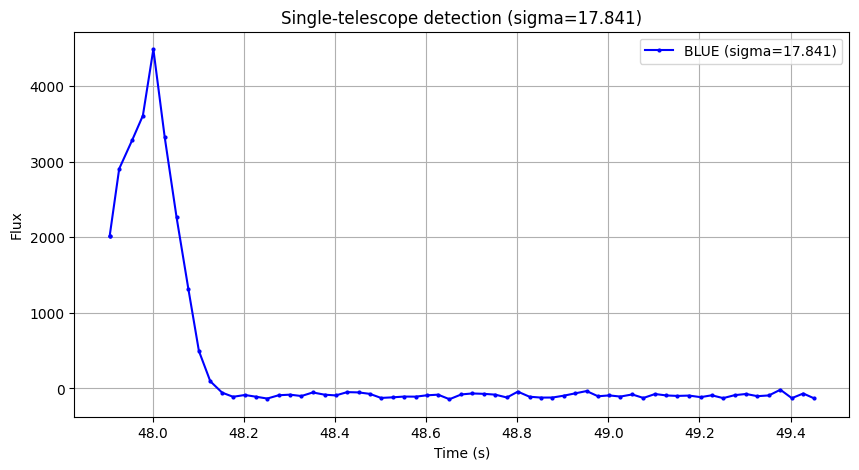

Star coords: [262.723783 918.614085]
Raw lightcurve mean: -90.6222
Raw lightcurve std:  188.637
Raw lightcurve min:  -143.08
Significance of minimum: 0.278


In [11]:
# Inspect one high-significance single-telescope detection.
hs_idx = 0   # rank within sorted_dets[INSPECT_TEL]

insp_tel = TEL_BY_NAME[INSPECT_TEL]
insp_file, insp_sig = sorted_dets[INSPECT_TEL][hs_idx]
insp_df, insp_meta = load_lightcurve(insp_tel, insp_file)
insp_filepaths = [rcd_path(insp_tel, p) for p in insp_df["filename"].values]
insp_star_coords = get_star_coords(insp_tel.archive_date, insp_file)
print(f"Detection file: {insp_file}")

plt.figure(figsize=(10, 5))
plt.plot(insp_df["time"], insp_df["flux"], color=insp_tel.color, marker="o", markersize=2,
         label=f"{INSPECT_TEL} (sigma={insp_sig})")
plt.xlabel("Time (s)"); plt.ylabel("Flux")
plt.title(f"Single-telescope detection (sigma={insp_sig})")
plt.legend(); plt.grid(); plt.show()

# Recompute the significance of the deepest point from the header stats.
mean = float(insp_meta["Raw lightcurve mean"])
std  = float(insp_meta["Raw lightcurve std"])
min_flux = insp_df["flux"].min()
print(f"Star coords: {insp_star_coords}")
print(f"Raw lightcurve mean: {mean}")
print(f"Raw lightcurve std:  {std}")
print(f"Raw lightcurve min:  {min_flux}")
print(f"Significance of minimum: {abs((min_flux - mean) / std):.3f}")

# Full light curve

In [12]:
# Full per-minute star data (_stars.npy) for the inspected detection's minute.
# Shape (n_frames, n_stars, 4) = [x, y, flux, unix_time]; this is the array the
# verification timing-check reads.
ev = get_event_datetime(insp_file)
md = find_minute_dir(insp_tel, ev)
if md is None:
    print(f"{INSPECT_TEL} was not observing at {ev} (no minute dir).")
else:
    hits = glob.glob(os.path.join(insp_tel.archive_date, f"{md[0]}_stars.npy"))
    if hits:
        stars = np.load(hits[0], allow_pickle=True)
        print(f"{os.path.basename(hits[0])}: shape {stars.shape}  "
              f"(frames x stars x [x, y, flux, unix_time])")
    else:
        print(f"No _stars.npy for {md[0]} -- minute not processed.")

20260616_08.03.47.755_stars.npy: shape (2399, 112, 4)  (frames x stars x [x, y, flux, unix_time])


# Lightcurve makers

KeyboardInterrupt: 

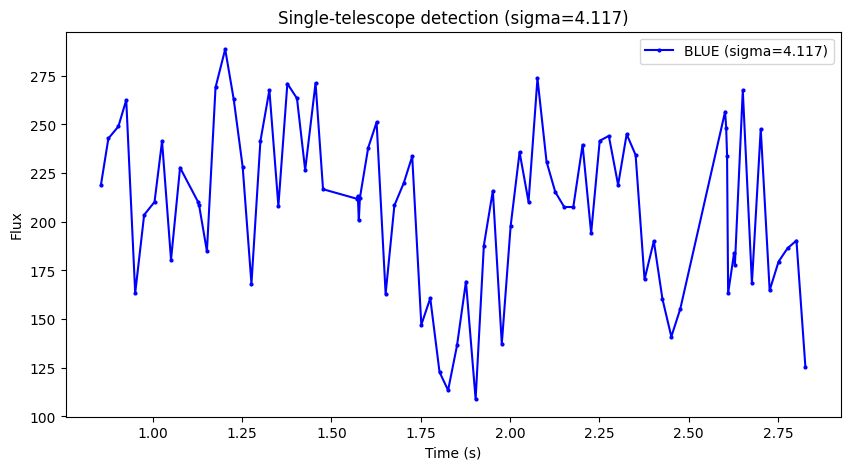

In [13]:
# Batch: save a light-curve PNG for every detection on a telescope.
def batch_plot_lightcurves(tel, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    for f, s in sort_by_significance(tel):
        try:
            df, _ = load_lightcurve(tel, f)
            plt.figure(figsize=(10, 5))
            plt.plot(df["time"], df["flux"], color=tel.color, marker="o", markersize=2,
                     label=f"{tel.name} (sigma={s})")
            plt.xlabel("Time (s)"); plt.ylabel("Flux")
            plt.title(f"Single-telescope detection (sigma={s})"); plt.legend()
            plt.savefig(os.path.join(output_dir, f"{os.path.splitext(f)[0]}.png"))
            plt.close()
        except Exception as e:
            print(f"Error processing {f}: {e}")
    print(f"All plots saved to {output_dir}")


batch_plot_lightcurves(
    TEL_BY_NAME[INSPECT_TEL],
    rf"C:\Users\GreenBird\Documents\Python Scripts\agirmen\lightcurve_plots_{OBS_DATE}_{INSPECT_TEL.lower()}",
)

In [ ]:
# Same, for GREEN (change the telescope name as needed).
batch_plot_lightcurves(
    TEL_BY_NAME["GREEN"],
    rf"C:\Users\GreenBird\Documents\Python Scripts\agirmen\lightcurve_plots_{OBS_DATE}_green",
)

# Occultation images

In [ ]:
# add a circle to the image at the star coords
from matplotlib.patches import Circle

def plot_images_in_grid(images, times, star_coords, zoom_size=50):
    """
    Plots images in a 3x3 grid, zoomed around the star's coordinates, with times in the titles.
    vmin and vmax are based on the first zoomed image.
    
    Parameters:
        images (list of np.ndarray): List of image arrays.
        times (list of str): List of times corresponding to each image (as strings).
        star_coords (tuple): Coordinates of the star (x, y).
        zoom_size (int): Half the size of the zoomed region around the star.
    """
    # Extract the first zoomed image to determine vmin and vmax
    x, y = int(star_coords[0]), int(star_coords[1])
    first_zoomed_image = images[0][max(0, y-zoom_size):y+zoom_size, max(0, x-zoom_size):x+zoom_size]
    vmin, vmax = np.min(first_zoomed_image), np.max(first_zoomed_image)
    # alternative vmin and vmax of area 5x the zoom size around the star
    # vmin, vmax = np.min(images[0][max(0, y-5*zoom_size):y+5*zoom_size, max(0, x-5*zoom_size):x+5*zoom_size]), np.max(images[0][max(0, y-5*zoom_size):y+5*zoom_size, max(0, x-5*zoom_size):x+5*zoom_size])
    



    num_images = len(images)
    for i in range(0, num_images, 9):
        fig, axes = plt.subplots(3, 3, figsize=(20, 20))
        fig.suptitle(f"Images {i+1} to {min(i+9, num_images)}", fontsize=16)
        
        for j, ax in enumerate(axes.flat):
            if i + j < num_images:
                image = images[i + j]
                time = times[i + j]  # Use the string time directly
                
                # Extract zoomed region
                zoomed_image = image[max(0, y-zoom_size):y+zoom_size, max(0, x-zoom_size):x+zoom_size]
                
                # Plot the zoomed image without logarithmic scaling
                ax.imshow(zoomed_image, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)


                # Add a circle around x-y
                circle = Circle(star_coords, 10, color='red', fill=False, linewidth=2)
                ax.add_patch(circle)
                ax.set_title(f"Image {i + j + 1}\nTime: {time}")
                ax.axis('off')
            else:
                ax.axis('off')  # Hide unused subplots
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)  # Adjust for the title
        plt.show()

In [ ]:
# Zoomed image grid around the star, across frames, for the inspected detection
# (insp_filepaths / insp_star_coords come from the high-sig inspection cell above).
all_rcd_images, grid_times = cir.importFramesRCD(insp_filepaths, 0, 80)
plot_images_in_grid(all_rcd_images, grid_times, insp_star_coords, zoom_size=50)